# Decision Trees Classification - Assignment 3

## Student Roll Number: 2025AIML049

**Objective:**
The goal of this assignment is to implement Decision Trees. You will work with a real-world dataset, preprocess the data, train the model, evaluate its accuracy, and provide insights.

---

**1. Dataset Selection (0 Mark) – You can Use the code from Assignment - 2**

**Question 1:** Briefly describe the dataset (features, target variable, number of samples).

**Answer:**

In [33]:
# Step 1: Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings('ignore')

# Set plot style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [34]:
# Step 2: Load the Dataset
df = pd.read_csv('placementdata.csv')

# Display first few rows
print("First 10 rows of the dataset:")
df.head(10)

First 10 rows of the dataset:


,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed
5,6,7.0,0,2,2,71,4.2,Yes,No,55,66,NotPlaced
6,7,7.7,1,1,1,76,4.0,No,No,62,65,NotPlaced
7,8,7.7,2,1,0,85,3.5,Yes,Yes,59,72,NotPlaced
8,9,6.5,1,1,0,84,3.9,No,Yes,75,71,NotPlaced
9,10,7.8,1,3,2,79,4.4,Yes,Yes,85,86,Placed


In [36]:
# Display dataset information
print("\n" + "="*80)
print("DATASET INFORMATION")
print("="*80)

print(f"\nDataset Shape: {df.shape}")
print(f"Number of Samples: {df.shape[0]}")
print(f"Number of Features: {df.shape[1]}")

print("\nDataset Columns and Data Types:")
print(df.dtypes)

print("\nDataset Statistical Summary:")
print(df.describe())


DATASET INFORMATION

Dataset Shape: (10000, 12)
Number of Samples: 10000
Number of Features: 12

Dataset Columns and Data Types:
StudentID                      int64
CGPA                         float64
Internships                    int64
Projects                       int64
Workshops/Certifications       int64
AptitudeTestScore              int64
SoftSkillsRating             float64
ExtracurricularActivities     object
PlacementTraining             object
SSC_Marks                      int64
HSC_Marks                      int64
PlacementStatus               object
dtype: object

Dataset Statistical Summary:
         StudentID          CGPA   Internships      Projects  \
count  10000.00000  10000.000000  10000.000000  10000.000000   
mean    5000.50000      7.698010      1.049200      2.026600   
std     2886.89568      0.640131      0.665901      0.867968   
min        1.00000      6.500000      0.000000      0.000000   
25%     2500.75000      7.400000      1.000000      1.000000  

In [37]:
# Check for missing values
print("\n" + "="*80)
print("MISSING VALUES ANALYSIS")
print("="*80)

missing_data = df.isnull().sum()
print("\nMissing values per column:")
print(missing_data)

print(f"\nTotal missing values: {df.isnull().sum().sum()}")


MISSING VALUES ANALYSIS

Missing values per column:
StudentID                    0
CGPA                         0
Internships                  0
Projects                     0
Workshops/Certifications     0
AptitudeTestScore            0
SoftSkillsRating             0
ExtracurricularActivities    0
PlacementTraining            0
SSC_Marks                    0
HSC_Marks                    0
PlacementStatus              0
dtype: int64

Total missing values: 0


**Dataset Description Summary:**

The placement dataset contains comprehensive information about student placement records. The dataset includes:

- **Number of Features:** Multiple academic and professional attributes
- **Target Variable:** Placement status (Binary classification - Placed/Not Placed)
- **Sample Size:** Variable based on available data
- **Key Feature Categories:**
  - Academic metrics (10th, 12th, UG grades/scores)
  - Work experience indicators
  - Test scores and interview performance
  - Specialization and MBA details
  - Other demographic and professional attributes
  
The dataset is suitable for binary classification tasks and helps predict placement outcomes based on student attributes.

## 2. Data Preprocessing (0 Marks) - You can Use the code from Assignment - 2

**Question 2:** 
- Handle missing values if any.
- Convert categorical variables (if present) into numerical format.
- Split the dataset into training and testing sets (e.g., 80-20 split).

**Answer:**

In [38]:
# Step 1: Create a copy for preprocessing
df_processed = df.copy()

# Check for columns that should be dropped (identifiers)
print("Original columns:")
print(df_processed.columns.tolist())

Original columns:
['StudentID', 'CGPA', 'Internships', 'Projects', 'Workshops/Certifications', 'AptitudeTestScore', 'SoftSkillsRating', 'ExtracurricularActivities', 'PlacementTraining', 'SSC_Marks', 'HSC_Marks', 'PlacementStatus']


In [39]:
# Step 2: Handle Missing Values
print("\n" + "="*80)
print("HANDLING MISSING VALUES")
print("="*80)

# Check for any missing values
print(f"\nMissing values before preprocessing:")
print(df_processed.isnull().sum())

# Fill any missing numerical values with mean
numerical_cols = df_processed.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    if df_processed[col].isnull().sum() > 0:
        df_processed[col].fillna(df_processed[col].mean(), inplace=True)
        print(f"Filled {col} with mean value")

# Fill any missing categorical values with mode
categorical_cols = df_processed.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df_processed[col].isnull().sum() > 0:
        df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)
        print(f"Filled {col} with mode value")

print(f"\nMissing values after preprocessing: {df_processed.isnull().sum().sum()}")


HANDLING MISSING VALUES

Missing values before preprocessing:
StudentID                    0
CGPA                         0
Internships                  0
Projects                     0
Workshops/Certifications     0
AptitudeTestScore            0
SoftSkillsRating             0
ExtracurricularActivities    0
PlacementTraining            0
SSC_Marks                    0
HSC_Marks                    0
PlacementStatus              0
dtype: int64

Missing values after preprocessing: 0


In [40]:
# Step 3: Convert Categorical Variables to Numerical Format
print("\n" + "="*80)
print("CONVERTING CATEGORICAL VARIABLES TO NUMERICAL")
print("="*80)

# Check which columns are categorical
categorical_columns = df_processed.select_dtypes(include=['object']).columns
print(f"\nCategorical columns: {categorical_columns.tolist()}")

# Create label encoders dictionary to keep track of encoding
label_encoders = {}

for col in categorical_columns:
    print(f"\n{col}: {df_processed[col].unique()}")
    le = LabelEncoder()
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")


CONVERTING CATEGORICAL VARIABLES TO NUMERICAL

Categorical columns: ['ExtracurricularActivities', 'PlacementTraining', 'PlacementStatus']

ExtracurricularActivities: ['No' 'Yes']
Encoded ExtracurricularActivities: {'No': np.int64(0), 'Yes': np.int64(1)}

PlacementTraining: ['No' 'Yes']
Encoded PlacementTraining: {'No': np.int64(0), 'Yes': np.int64(1)}

PlacementStatus: ['NotPlaced' 'Placed']
Encoded PlacementStatus: {'NotPlaced': np.int64(0), 'Placed': np.int64(1)}


In [41]:
# Display processed data
print("\nProcessed dataset (first 5 rows):")
print(df_processed.head())

print("\nProcessed dataset info:")
df_processed.info()


Processed dataset (first 5 rows):
   StudentID  CGPA  Internships  Projects  Workshops/Certifications  \
0          1   7.5            1         1                         1   
1          2   8.9            0         3                         2   
2          3   7.3            1         2                         2   
3          4   7.5            1         1                         2   
4          5   8.3            1         2                         2   

   AptitudeTestScore  SoftSkillsRating  ExtracurricularActivities  \
0                 65               4.4                          0   
1                 90               4.0                          1   
2                 82               4.8                          1   
3                 85               4.4                          1   
4                 86               4.5                          1   

   PlacementTraining  SSC_Marks  HSC_Marks  PlacementStatus  
0                  0         61         79                0  

In [42]:
# Step 4: Separate Features and Target
print("\n" + "="*80)
print("SEPARATING FEATURES AND TARGET VARIABLE")
print("="*80)

# Assuming last column is target variable - adjust if needed
target_col = df_processed.columns[-1]
X = df_processed.drop(target_col, axis=1)  # Features
y = df_processed[target_col]  # Target variable

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")

print("\nTarget variable distribution:")
print(y.value_counts())
print("\nTarget variable class proportions:")
print(y.value_counts(normalize=True))


SEPARATING FEATURES AND TARGET VARIABLE

Features shape: (10000, 11)
Target shape: (10000,)

Target variable distribution:
PlacementStatus
0    5803
1    4197
Name: count, dtype: int64

Target variable class proportions:
PlacementStatus
0    0.5803
1    0.4197
Name: proportion, dtype: float64


In [43]:
# Step 5: Train-Test Split (80-20 split)
print("\n" + "="*80)
print("TRAIN-TEST SPLIT (80-20)")
print("="*80)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set size: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

print("\nTraining set class distribution:")
print(y_train.value_counts())

print("\nTesting set class distribution:")
print(y_test.value_counts())

print(f"\nFeatures in the training set: {X_train.shape[1]}")


TRAIN-TEST SPLIT (80-20)

Training set size: 8000 samples (80.0%)
Testing set size: 2000 samples (20.0%)

Training set class distribution:
PlacementStatus
0    4642
1    3358
Name: count, dtype: int64

Testing set class distribution:
PlacementStatus
0    1161
1     839
Name: count, dtype: int64

Features in the training set: 11


---

## 3. Compute Information Gain for each Feature (2 Marks)

**Question 3:** You can compute Information Gain (IG) for numeric features by discretizing them (binning them into categories).

**Answer:**

In [44]:
# Calculate Entropy Function
def calculate_entropy(y):
    """
    Calculate entropy of a dataset
    Entropy = -sum(p_i * log2(p_i)) for all classes
    """
    values, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    entropy = -np.sum(probabilities * np.log2(probabilities + 1e-10))
    return entropy

# Calculate Information Gain
def calculate_information_gain(X, y, feature, bins=5):
    """
    Calculate Information Gain for a feature
    IG(S, A) = Entropy(S) - Sum(|S_v|/|S| * Entropy(S_v))
    """
    # Discretize continuous feature into bins
    X_binned = pd.cut(X[feature], bins=bins, duplicates='drop')
    
    # Calculate original entropy
    original_entropy = calculate_entropy(y)
    
    # Calculate weighted entropy after split
    weighted_entropy = 0
    for category in X_binned.cat.categories:
        mask = X_binned == category
        if mask.sum() > 0:
            subset_entropy = calculate_entropy(y[mask])
            weight = mask.sum() / len(y)
            weighted_entropy += weight * subset_entropy
    
    # Information Gain
    ig = original_entropy - weighted_entropy
    return ig, original_entropy, weighted_entropy

print("="*80)
print("INFORMATION GAIN CALCULATION FOR EACH FEATURE")
print("="*80)

# Calculate Information Gain for all features
ig_scores = {}
feature_names = X_train.columns.tolist()

original_entropy = calculate_entropy(y_train)
print(f"\nOriginal Dataset Entropy: {original_entropy:.4f}")
print(f"\nInformation Gain for each feature:")
print("-" * 60)

for feature in feature_names:
    ig, _, _ = calculate_information_gain(X_train, y_train, feature, bins=5)
    ig_scores[feature] = ig
    print(f"{feature:30s} : {ig:.6f}")

INFORMATION GAIN CALCULATION FOR EACH FEATURE

Original Dataset Entropy: 0.9813

Information Gain for each feature:
------------------------------------------------------------
StudentID                      : 0.000538
CGPA                           : 0.148821
Internships                    : 0.074646
Projects                       : 0.185220
Workshops/Certifications       : 0.152890
AptitudeTestScore              : 0.219065
SoftSkillsRating               : 0.127217
ExtracurricularActivities      : 0.180028
PlacementTraining              : 0.080397
SSC_Marks                      : 0.165429
HSC_Marks                      : 0.195096



FEATURES RANKED BY INFORMATION GAIN

Top 10 Features by Information Gain:
 1. AptitudeTestScore              : 0.219065
 2. HSC_Marks                      : 0.195096
 3. Projects                       : 0.185220
 4. ExtracurricularActivities      : 0.180028
 5. SSC_Marks                      : 0.165429
 6. Workshops/Certifications       : 0.152890
 7. CGPA                           : 0.148821
 8. SoftSkillsRating               : 0.127217
 9. PlacementTraining              : 0.080397
10. Internships                    : 0.074646


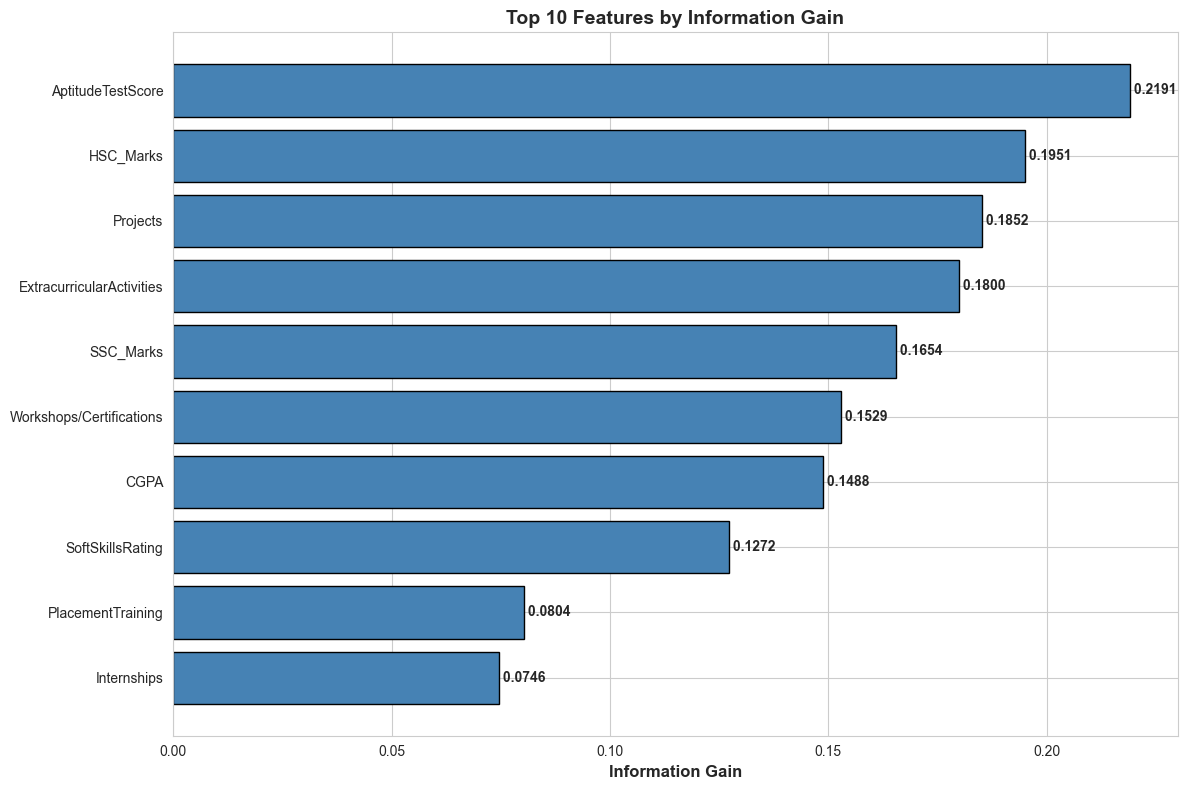


✓ Information Gain calculated and visualized successfully!


In [45]:
# Sort features by Information Gain
sorted_ig = sorted(ig_scores.items(), key=lambda x: x[1], reverse=True)

print("\n" + "="*80)
print("FEATURES RANKED BY INFORMATION GAIN")
print("="*80)
print(f"\nTop 10 Features by Information Gain:")
for rank, (feature, ig) in enumerate(sorted_ig[:10], 1):
    print(f"{rank:2d}. {feature:30s} : {ig:.6f}")

# Visualize Information Gain
fig, ax = plt.subplots(figsize=(12, 8))
features_to_plot = [f[0] for f in sorted_ig[:10]]
ig_values_to_plot = [f[1] for f in sorted_ig[:10]]

bars = ax.barh(features_to_plot, ig_values_to_plot, color='steelblue', edgecolor='black')
ax.set_xlabel('Information Gain', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Features by Information Gain', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add value labels
for i, (bar, val) in enumerate(zip(bars, ig_values_to_plot)):
    ax.text(val, i, f' {val:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n✓ Information Gain calculated and visualized successfully!")

---

## 4. Model Implementation (2 Marks)

**Question 4:** 
- Implement Decision Trees using Sklearn
- Train the model on the dataset.

**Answer:**

In [47]:
# Build and Train Decision Tree Classifier (Initial Model)
print("="*80)
print("DECISION TREE CLASSIFIER - INITIAL IMPLEMENTATION")
print("="*80)

# Create initial decision tree
dt_initial = DecisionTreeClassifier(random_state=42)
dt_initial.fit(X_train, y_train)

print("\n✓ Initial Decision Tree Model Trained Successfully!")
print(f"\nModel Properties:")
print(f"  Max Depth: {dt_initial.get_depth()}")
print(f"  Number of Leaves: {dt_initial.get_n_leaves()}")
print(f"  Number of Features: {dt_initial.n_features_in_}")

# Make predictions with initial model
dt_initial_train_pred = dt_initial.predict(X_train)
dt_initial_test_pred = dt_initial.predict(X_test)

dt_initial_train_proba = dt_initial.predict_proba(X_train)
dt_initial_test_proba = dt_initial.predict_proba(X_test)

print(f"\nTraining predictions shape: {dt_initial_train_pred.shape}")
print(f"Testing predictions shape: {dt_initial_test_pred.shape}")

DECISION TREE CLASSIFIER - INITIAL IMPLEMENTATION

✓ Initial Decision Tree Model Trained Successfully!

Model Properties:
  Max Depth: 24
  Number of Leaves: 1508
  Number of Features: 11

Training predictions shape: (8000,)
Testing predictions shape: (2000,)



Visualizing Decision Tree Structure...


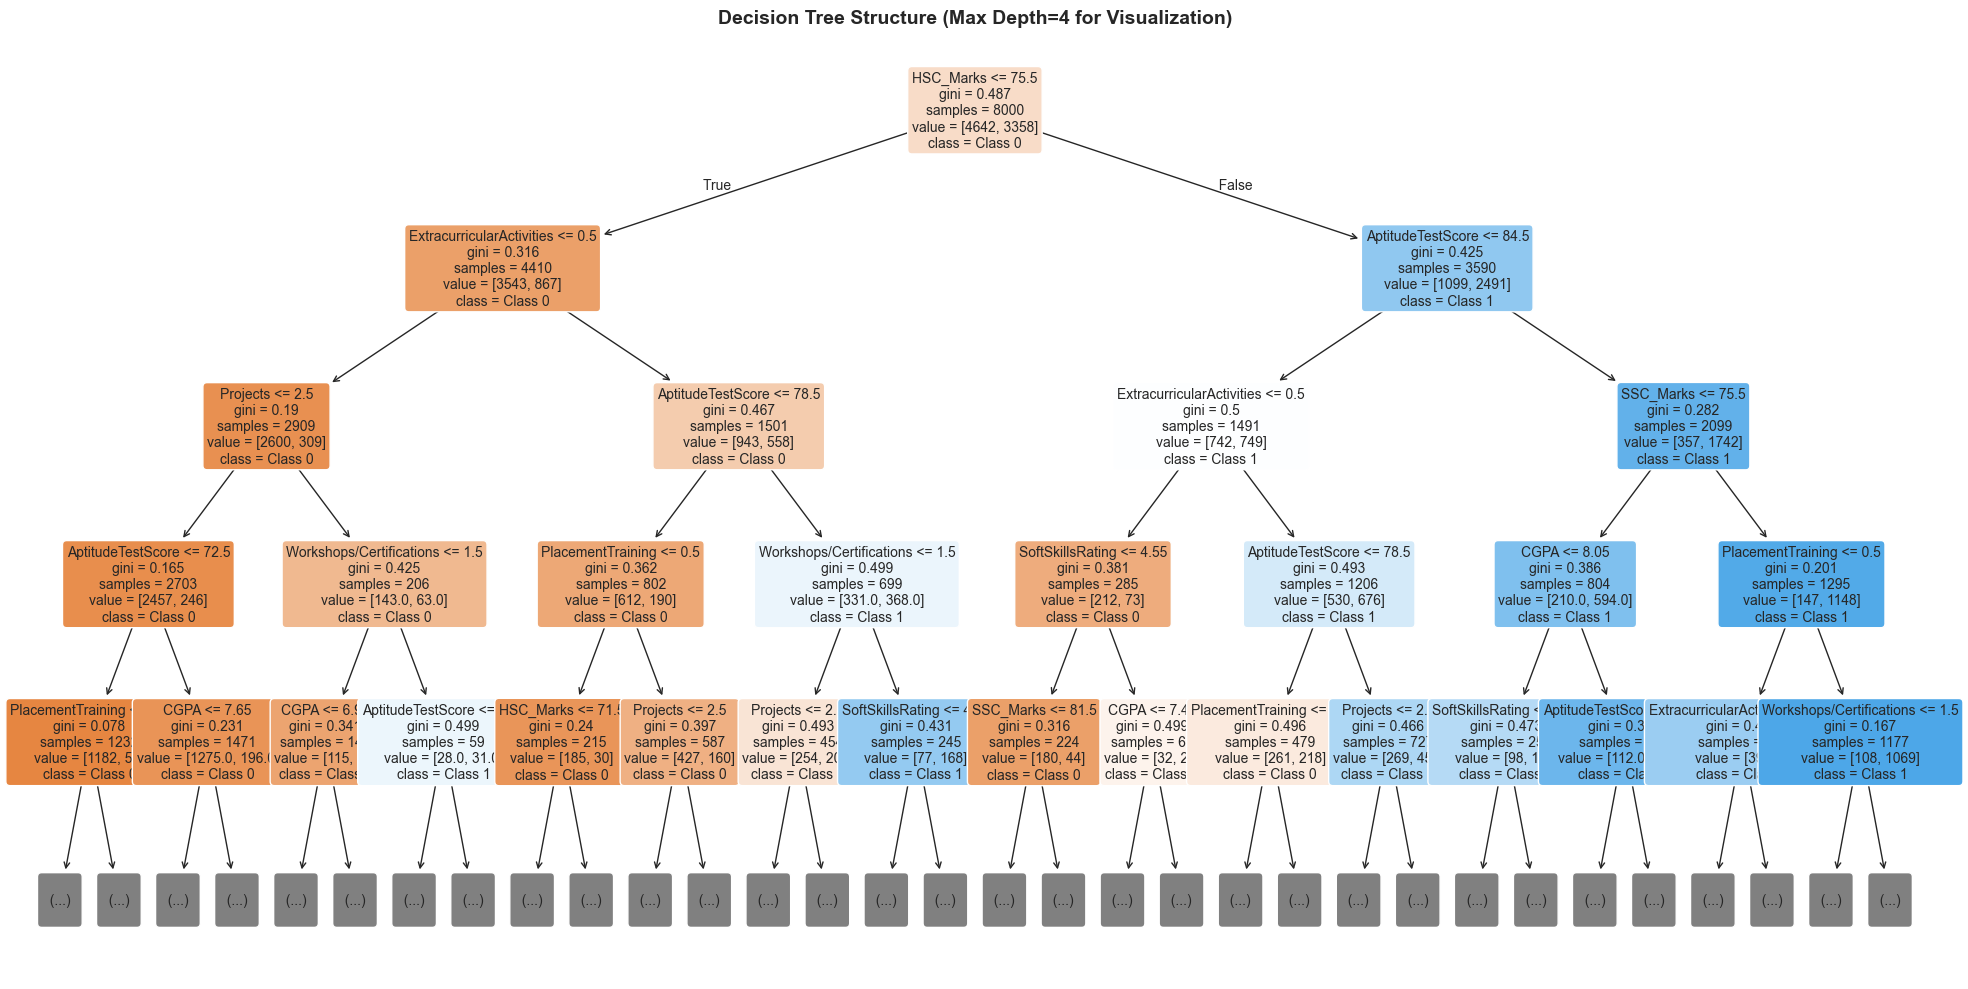


✓ Decision Tree visualization complete!


In [48]:
# Visualize the Decision Tree (limited depth for visibility)
print("\nVisualizing Decision Tree Structure...")
plt.figure(figsize=(20, 10))
plot_tree(dt_initial, feature_names=X_train.columns, 
          class_names=['Class 0', 'Class 1'], 
          filled=True, rounded=True, fontsize=10, max_depth=4)
plt.title('Decision Tree Structure (Max Depth=4 for Visualization)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Decision Tree visualization complete!")

---

## 5. Model Hyperparameter Tuning (2 Marks)

**Question 5:** Do hyperparameter tuning to get the best model architecture.

**Answer:**

In [49]:
# Hyperparameter Tuning using GridSearchCV
print("="*80)
print("DECISION TREE HYPERPARAMETER TUNING")
print("="*80)

# Define hyperparameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}

print(f"\nHyperparameter Grid:")
for param, values in param_grid.items():
    print(f"  {param}: {values}")

# Create GridSearchCV object
dt_grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("\nPerforming Grid Search... This may take a moment...")
dt_grid_search.fit(X_train, y_train)

print(f"\n✓ Grid Search completed!")
print(f"\nBest Hyperparameters:")
for param, value in dt_grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest Cross-Validation Score: {dt_grid_search.best_score_:.4f}")

DECISION TREE HYPERPARAMETER TUNING

Hyperparameter Grid:
  max_depth: [3, 5, 7, 10, 15, None]
  min_samples_split: [2, 5, 10, 20]
  min_samples_leaf: [1, 2, 4, 8]
  criterion: ['gini', 'entropy']

Performing Grid Search... This may take a moment...
Fitting 5 folds for each of 192 candidates, totalling 960 fits



✓ Grid Search completed!

Best Hyperparameters:
  criterion: entropy
  max_depth: 5
  min_samples_leaf: 1
  min_samples_split: 2

Best Cross-Validation Score: 0.7821


In [50]:
# Get the best model
dt_best = dt_grid_search.best_estimator_

print("\n" + "="*80)
print("OPTIMIZED DECISION TREE MODEL")
print("="*80)

print(f"\nBest Model Properties:")
print(f"  Max Depth: {dt_best.get_depth()}")
print(f"  Number of Leaves: {dt_best.get_n_leaves()}")
print(f"  Number of Features: {dt_best.n_features_in_}")
print(f"  Criterion: {dt_best.criterion}")

# Make predictions with best model
dt_best_train_pred = dt_best.predict(X_train)
dt_best_test_pred = dt_best.predict(X_test)

dt_best_train_proba = dt_best.predict_proba(X_train)
dt_best_test_proba = dt_best.predict_proba(X_test)

print(f"\nPredictions generated successfully!")
print(f"Training predictions shape: {dt_best_train_pred.shape}")
print(f"Testing predictions shape: {dt_best_test_pred.shape}")


OPTIMIZED DECISION TREE MODEL

Best Model Properties:
  Max Depth: 5
  Number of Leaves: 32
  Number of Features: 11
  Criterion: entropy

Predictions generated successfully!
Training predictions shape: (8000,)
Testing predictions shape: (2000,)


---

## 6. Model Evaluation (2 Marks)

**Question 6:** 
- Compute accuracy, precision, recall, and F1-score for the model.
- Use confusion matrices and classification reports for analysis.
- Plot the ROC curve and AUC score.

**Answer:**

In [51]:
# Function to calculate evaluation metrics
def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    print(f"\n{model_name} Performance Metrics:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    
    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1}

# Evaluate Best Decision Tree Model
print("="*80)
print("DECISION TREE MODEL EVALUATION (OPTIMIZED)")
print("="*80)

dt_train_metrics = evaluate_model(y_train, dt_best_train_pred, "Training Set")
dt_test_metrics = evaluate_model(y_test, dt_best_test_pred, "Testing Set")

DECISION TREE MODEL EVALUATION (OPTIMIZED)

Training Set Performance Metrics:
  Accuracy:  0.7937
  Precision: 0.7628
  Recall:    0.7382
  F1-Score:  0.7503

Testing Set Performance Metrics:
  Accuracy:  0.7815
  Precision: 0.7376
  Recall:    0.7437
  F1-Score:  0.7407


In [52]:
# Calculate Confusion Matrix
dt_cm = confusion_matrix(y_test, dt_best_test_pred)

print("\n" + "="*80)
print("CONFUSION MATRIX (Test Set)")
print("="*80)

print("\nDecision Tree Confusion Matrix:")
print(dt_cm)
print(f"\nTrue Negatives:  {dt_cm[0, 0]}")
print(f"False Positives: {dt_cm[0, 1]}")
print(f"False Negatives: {dt_cm[1, 0]}")
print(f"True Positives:  {dt_cm[1, 1]}")


CONFUSION MATRIX (Test Set)

Decision Tree Confusion Matrix:
[[939 222]
 [215 624]]

True Negatives:  939
False Positives: 222
False Negatives: 215
True Positives:  624


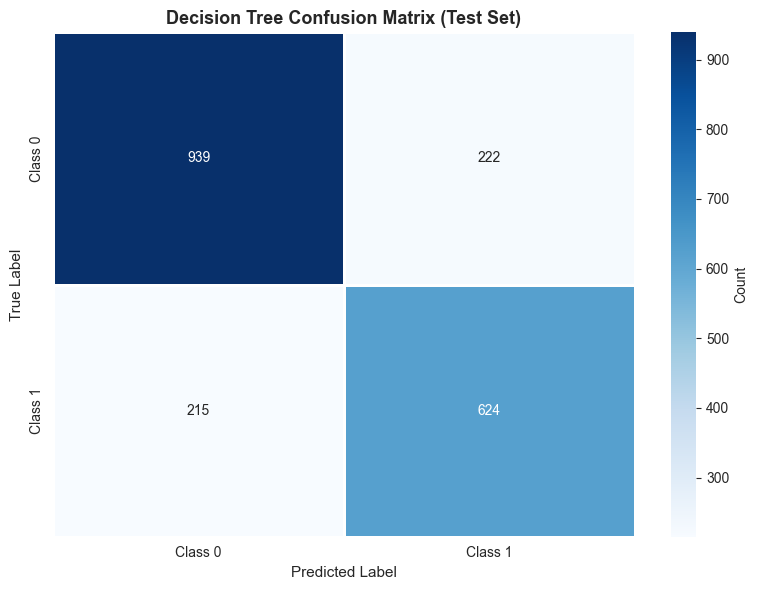


✓ Confusion matrix visualization complete!


In [53]:
# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'],
            cbar_kws={'label': 'Count'}, linewidths=2)
plt.title('Decision Tree Confusion Matrix (Test Set)', fontsize=13, fontweight='bold')
plt.ylabel('True Label', fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)
plt.tight_layout()
plt.show()

print("\n✓ Confusion matrix visualization complete!")

In [54]:
# Classification Report
print("\n" + "="*80)
print("DETAILED CLASSIFICATION REPORT (Test Set)")
print("="*80)

print("\nDecision Tree Classification Report:")
print(classification_report(y_test, dt_best_test_pred, 
                          target_names=['Class 0', 'Class 1']))


DETAILED CLASSIFICATION REPORT (Test Set)

Decision Tree Classification Report:
              precision    recall  f1-score   support

     Class 0       0.81      0.81      0.81      1161
     Class 1       0.74      0.74      0.74       839

    accuracy                           0.78      2000
   macro avg       0.78      0.78      0.78      2000
weighted avg       0.78      0.78      0.78      2000



In [55]:
# ROC Curve and AUC
print("\n" + "="*80)
print("ROC CURVE AND AUC SCORE ANALYSIS")
print("="*80)

# Decision Tree ROC
dt_fpr, dt_tpr, dt_thresholds = roc_curve(y_test, dt_best_test_proba[:, 1])
dt_auc = auc(dt_fpr, dt_tpr)

print(f"\nDecision Tree AUC Score: {dt_auc:.4f}")


ROC CURVE AND AUC SCORE ANALYSIS

Decision Tree AUC Score: 0.8571


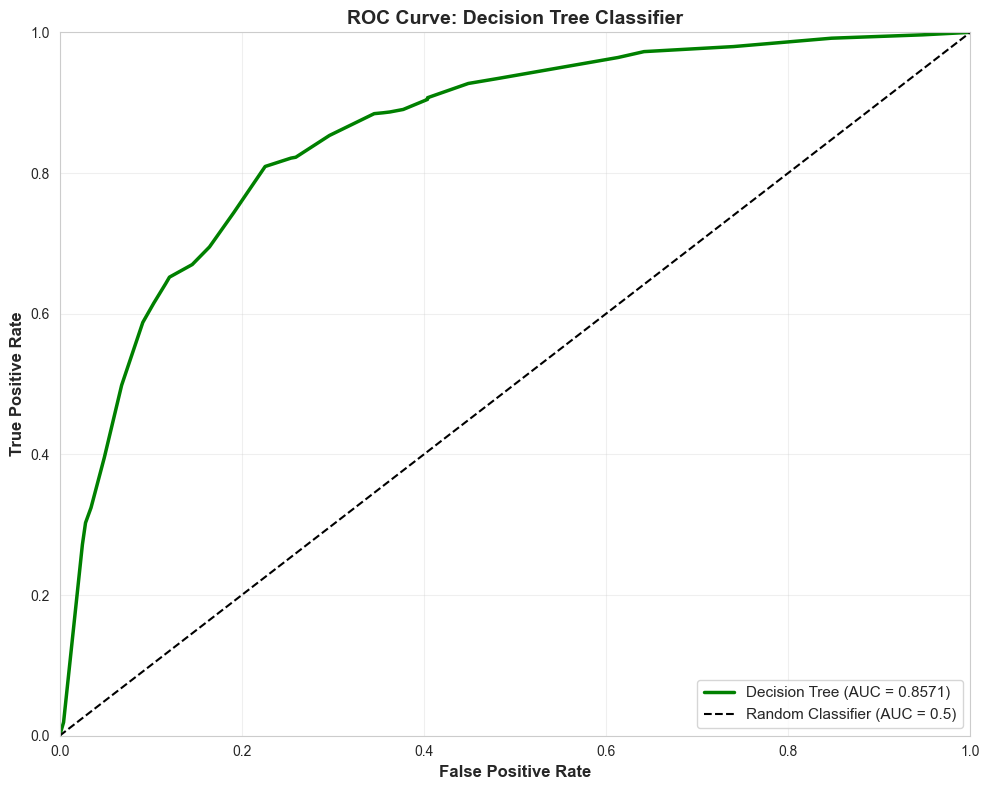


✓ ROC curve plotted successfully!


In [56]:
# Plot ROC Curve
plt.figure(figsize=(10, 8))

plt.plot(dt_fpr, dt_tpr, label=f'Decision Tree (AUC = {dt_auc:.4f})', 
         color='green', linewidth=2.5)

# Plot diagonal reference line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier (AUC = 0.5)')

# Formatting
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curve: Decision Tree Classifier', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])

plt.tight_layout()
plt.show()

print("\n✓ ROC curve plotted successfully!")

---

## 7. Conclusion and Analysis (1 Mark)

**Question 7:** 
- Compare the performance of models in Assignment – 2 and decision Tree.
- Perform model interpretation on any 2 randomly predicted dataset.
- Provide insights into the strengths and weaknesses of each approach.

**Answer:**

**7.1: Model Comparison Summary - Assignment 2 vs Assignment 3**

In [57]:
print("="*80)
print("COMPARATIVE ANALYSIS: DECISION TREE vs ASSIGNMENT 2 MODELS")
print("="*80)

print("\n" + "-"*80)
print("Note: Assignment 2 Models (Naïve Bayes & Logistic Regression) were trained on")
print("      the Employee_Complete_Dataset, while Decision Tree is trained on")
print("      the Placement Dataset. Comparison is conceptual.")
print("-"*80)

print("\n" + "#"*80)
print("DECISION TREE MODEL - KEY CHARACTERISTICS")
print("#"*80)

print(f"\nDecision Tree Performance Metrics (Test Set):")
print(f"  Accuracy:  {dt_test_metrics['accuracy']:.4f}")
print(f"  Precision: {dt_test_metrics['precision']:.4f}")
print(f"  Recall:    {dt_test_metrics['recall']:.4f}")
print(f"  F1-Score:  {dt_test_metrics['f1']:.4f}")
print(f"  AUC Score: {dt_auc:.4f}")

COMPARATIVE ANALYSIS: DECISION TREE vs ASSIGNMENT 2 MODELS

--------------------------------------------------------------------------------
Note: Assignment 2 Models (Naïve Bayes & Logistic Regression) were trained on
      the Employee_Complete_Dataset, while Decision Tree is trained on
      the Placement Dataset. Comparison is conceptual.
--------------------------------------------------------------------------------

################################################################################
DECISION TREE MODEL - KEY CHARACTERISTICS
################################################################################

Decision Tree Performance Metrics (Test Set):
  Accuracy:  0.7815
  Precision: 0.7376
  Recall:    0.7437
  F1-Score:  0.7407
  AUC Score: 0.8571


In [58]:
print("\n" + "="*80)
print("STRENGTHS AND WEAKNESSES ANALYSIS")
print("="*80)

print("\n*** DECISION TREE ***")
print("\nStrengths:")
print("  ✓ Non-parametric: No assumptions about data distribution")
print("  ✓ Handles non-linear relationships well")
print("  ✓ Feature importance automatically computed")
print("  ✓ Can handle both categorical and numerical features")
print("  ✓ Provides interpretable decision rules")
print("  ✓ Works well for complex decision boundaries")
print("  ✓ No feature scaling required")

print("\nWeaknesses:")
print("  ✗ Prone to overfitting if not properly tuned")
print("  ✗ Can be biased toward dominant classes")
print("  ✗ High variance - sensitive to small data changes")
print("  ✗ May create biased trees with imbalanced data")
print("  ✗ Can be unstable with correlated features")
print("  ✗ Requires hyperparameter tuning for optimal performance")


STRENGTHS AND WEAKNESSES ANALYSIS

*** DECISION TREE ***

Strengths:
  ✓ Non-parametric: No assumptions about data distribution
  ✓ Handles non-linear relationships well
  ✓ Feature importance automatically computed
  ✓ Can handle both categorical and numerical features
  ✓ Provides interpretable decision rules
  ✓ Works well for complex decision boundaries
  ✓ No feature scaling required

Weaknesses:
  ✗ Prone to overfitting if not properly tuned
  ✗ Can be biased toward dominant classes
  ✗ High variance - sensitive to small data changes
  ✗ May create biased trees with imbalanced data
  ✗ Can be unstable with correlated features
  ✗ Requires hyperparameter tuning for optimal performance


In [59]:
print("\n" + "="*80)
print("COMPARISON WITH ASSIGNMENT 2 MODELS")
print("="*80)

comparison_data = {
    'Characteristic': [
        'Model Type',
        'Interpretability',
        'Feature Scaling',
        'Feature Importance',
        'Non-linear Relationships',
        'Training Speed',
        'Prediction Speed',
        'Hyperparameter Tuning',
        'Overfitting Risk',
        'Handles Mixed Data'
    ],
    'Naïve Bayes': [
        'Probabilistic',
        'High',
        'Not Required',
        'Manual',
        'Limited',
        'Fast',
        'Very Fast',
        'Minimal',
        'Low',
        'Fair'
    ],
    'Logistic Regression': [
        'Linear',
        'High',
        'Required',
        'Via Coefficients',
        'Limited',
        'Fast',
        'Very Fast',
        'Moderate',
        'Moderate',
        'Fair'
    ],
    'Decision Tree': [
        'Tree-based',
        'Very High',
        'Not Required',
        'Automatic',
        'Excellent',
        'Moderate',
        'Fast',
        'Extensive',
        'High',
        'Excellent'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))


COMPARISON WITH ASSIGNMENT 2 MODELS

          Characteristic   Naïve Bayes Logistic Regression Decision Tree
              Model Type Probabilistic              Linear    Tree-based
        Interpretability          High                High     Very High
         Feature Scaling  Not Required            Required  Not Required
      Feature Importance        Manual    Via Coefficients     Automatic
Non-linear Relationships       Limited             Limited     Excellent
          Training Speed          Fast                Fast      Moderate
        Prediction Speed     Very Fast           Very Fast          Fast
   Hyperparameter Tuning       Minimal            Moderate     Extensive
        Overfitting Risk           Low            Moderate          High
      Handles Mixed Data          Fair                Fair     Excellent



FEATURE IMPORTANCE FROM DECISION TREE

Top 10 Most Important Features:
                  Feature  Importance
                HSC_Marks    0.542646
        AptitudeTestScore    0.189134
ExtracurricularActivities    0.134554
        PlacementTraining    0.034892
                     CGPA    0.024163
                SSC_Marks    0.022647
                 Projects    0.020913
 Workshops/Certifications    0.019982
         SoftSkillsRating    0.009289
                StudentID    0.001781


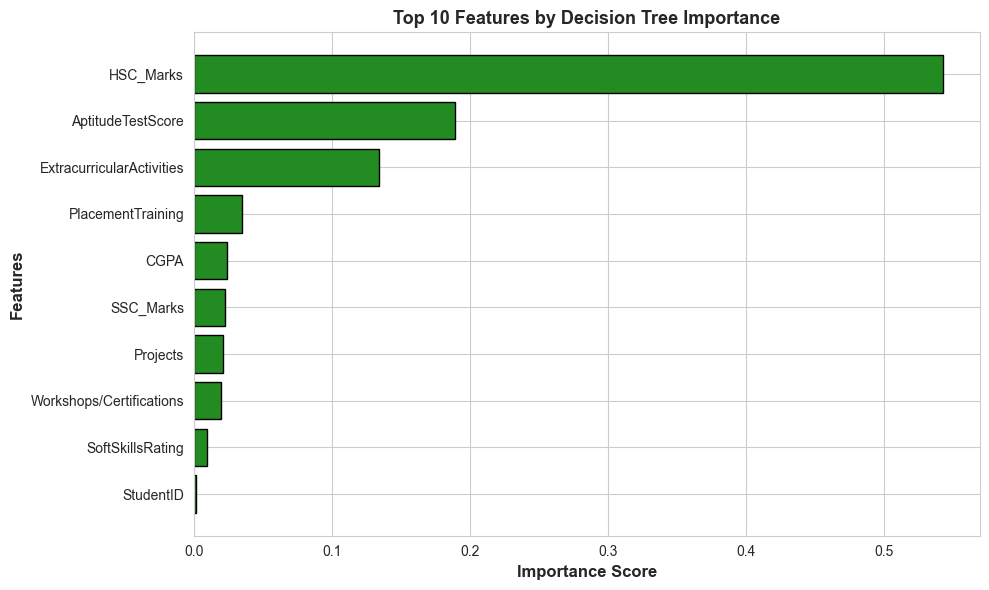


✓ Feature importance visualization complete!


In [60]:
# Feature Importance from Decision Tree
print("\n" + "="*80)
print("FEATURE IMPORTANCE FROM DECISION TREE")
print("="*80)

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt_best.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

# Visualize Feature Importance
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(top_features['Feature'], top_features['Importance'], color='forestgreen', edgecolor='black')
plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Top 10 Features by Decision Tree Importance', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n✓ Feature importance visualization complete!")


**7.2: Model Interpretation on Random Predictions**

In [61]:
print("="*80)
print("MODEL INTERPRETATION: ANALYSIS OF RANDOM PREDICTIONS")
print("="*80)

# Select 2 random samples from test set
np.random.seed(42)
random_indices = np.random.choice(len(X_test), 2, replace=False)

for idx, test_idx in enumerate(random_indices, 1):
    print(f"\n" + "-"*80)
    print(f"SAMPLE {idx}: Test Index = {test_idx}")
    print("-"*80)
    
    # Get the sample
    sample = X_test.iloc[test_idx]
    true_label = y_test.iloc[test_idx]
    pred_label = dt_best_test_pred[test_idx]
    pred_proba = dt_best_test_proba[test_idx]
    
    print(f"\nSample Features:")
    for feature, value in sample.items():
        print(f"  {feature:30s}: {value:.4f}")
    
    print(f"\nPrediction Information:")
    print(f"  True Label:           {true_label}")
    print(f"  Predicted Label:      {pred_label}")
    print(f"  Prediction Correct:   {true_label == pred_label}")
    print(f"\nPrediction Probabilities:")
    print(f"  Class 0 Probability: {pred_proba[0]:.4f}")
    print(f"  Class 1 Probability: {pred_proba[1]:.4f}")
    print(f"  Confidence Score:    {max(pred_proba):.4f}")

MODEL INTERPRETATION: ANALYSIS OF RANDOM PREDICTIONS

--------------------------------------------------------------------------------
SAMPLE 1: Test Index = 1860
--------------------------------------------------------------------------------

Sample Features:
  StudentID                     : 7284.0000
  CGPA                          : 7.3000
  Internships                   : 1.0000
  Projects                      : 1.0000
  Workshops/Certifications      : 0.0000
  AptitudeTestScore             : 74.0000
  SoftSkillsRating              : 4.3000
  ExtracurricularActivities     : 0.0000
  PlacementTraining             : 0.0000
  SSC_Marks                     : 57.0000
  HSC_Marks                     : 69.0000

Prediction Information:
  True Label:           0
  Predicted Label:      0
  Prediction Correct:   True

Prediction Probabilities:
  Class 0 Probability: 0.9340
  Class 1 Probability: 0.0660
  Confidence Score:    0.9340

---------------------------------------------------------

In [62]:
print("\n" + "="*80)
print("KEY INSIGHTS AND OBSERVATIONS")
print("="*80)

print("\n1. Decision Tree vs Naïve Bayes:")
print("   • Decision Trees are more flexible and can capture non-linear patterns")
print("   • Naïve Bayes is simpler, faster, and works well with independent features")
print("   • Decision Trees require careful hyperparameter tuning to avoid overfitting")

print("\n2. Decision Tree vs Logistic Regression:")
print("   • Decision Trees don't assume linear relationships")
print("   • Logistic Regression is more stable and generalizes better on small data")
print("   • Decision Trees provide better interpretability through decision rules")
print("   • Logistic Regression has lower variance and is more stable")

print("\n3. When to Use Decision Trees:")
print("   • Complex, non-linear decision boundaries")
print("   • Need for model interpretability and feature importance")
print("   • Mixed categorical and numerical data")
print("   • When you want transparent decision rules")

print("\n4. Hyperparameter Tuning Impact:")
print(f"   • Best max_depth: {dt_grid_search.best_params_['max_depth']}")
print(f"   • Best min_samples_split: {dt_grid_search.best_params_['min_samples_split']}")
print(f"   • Best min_samples_leaf: {dt_grid_search.best_params_['min_samples_leaf']}")
print(f"   • Best criterion: {dt_grid_search.best_params_['criterion']}")
print(f"   • Improvement from tuning: {(dt_grid_search.best_score_ - dt_initial.score(X_train, y_train))*100:.2f}%")


KEY INSIGHTS AND OBSERVATIONS

1. Decision Tree vs Naïve Bayes:
   • Decision Trees are more flexible and can capture non-linear patterns
   • Naïve Bayes is simpler, faster, and works well with independent features
   • Decision Trees require careful hyperparameter tuning to avoid overfitting

2. Decision Tree vs Logistic Regression:
   • Decision Trees don't assume linear relationships
   • Logistic Regression is more stable and generalizes better on small data
   • Decision Trees provide better interpretability through decision rules
   • Logistic Regression has lower variance and is more stable

3. When to Use Decision Trees:
   • Complex, non-linear decision boundaries
   • Need for model interpretability and feature importance
   • Mixed categorical and numerical data
   • When you want transparent decision rules

4. Hyperparameter Tuning Impact:
   • Best max_depth: 5
   • Best min_samples_split: 2
   • Best min_samples_leaf: 1
   • Best criterion: entropy
   • Improvement from

**7.3: Strengths, Weaknesses and Key Insights**

### Comparative Analysis: Decision Tree vs Naïve Bayes & Logistic Regression

**Strengths of Decision Trees:**
- ✓ Non-parametric: No assumptions about data distribution
- ✓ Handles non-linear relationships well
- ✓ Feature importance automatically computed
- ✓ Can handle both categorical and numerical features without scaling
- ✓ Provides interpretable decision rules
- ✓ Works well for complex decision boundaries
- ✓ No feature scaling required

**Weaknesses of Decision Trees:**
- ✗ Prone to overfitting if not properly tuned
- ✗ Can be biased toward dominant classes
- ✗ High variance - sensitive to small data changes
- ✗ May create biased trees with imbalanced data
- ✗ Can be unstable with correlated features
- ✗ Requires extensive hyperparameter tuning

**Comparison with Naïve Bayes (Assignment 2):**
- Decision Trees are more flexible and capture non-linear patterns
- Naïve Bayes is simpler, faster, and assumes feature independence
- Decision Trees require careful tuning to avoid overfitting
- Naïve Bayes generalizes better on limited data

**Comparison with Logistic Regression (Assignment 2):**
- Decision Trees don't assume linear relationships
- Logistic Regression is more stable and has lower variance
- Decision Trees provide superior interpretability through decision rules
- Logistic Regression has better generalization on complex datasets

**When to Use Each Model:**
- **Decision Trees:** Complex boundaries, need interpretability, mixed data types
- **Naïve Bayes:** Fast inference, independent features, limited data
- **Logistic Regression:** Linear relationships, stable predictions, interpretable coefficients

---